In [1]:
import numpy as np
from tqdm import tqdm
import math as m
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata

In [2]:
xmin=0;xmax=400.e3
ymin=0;zmax=200.e3

In [20]:
df = pd.read_csv("text_files/base_vel_comp.txt", sep="\s+", skiprows=2, header = None)
df.columns=['x','y','vx','vy']
df.x = df.x
df.y = (zmax-df.y)

In [21]:
xnum=1200; znum=600
# geometry parameters
# create input y-coordinates (with refined region at shallow depth)
zbound = 200.e3    # depth of refinement boundary
num_refine = 600   # number of grid points in refined upper layer
lower_lowres = np.linspace(0,zmax-zbound,znum+1-num_refine)
upper_highres = np.linspace(zmax-zbound,zmax,1+num_refine)
zvals = np.concatenate((lower_lowres, upper_highres[1:]), axis=0)
dx = 200.e3/600
dy = 400.e3/1200

In [22]:
x_low = np.linspace(xmin,xmax,int((xmax-xmin)/dx))
z_low = np.linspace(ymin,zmax,int((zmax-ymin)/dy))
X_low, Z_low = np.meshgrid(x_low,z_low)
# print((xmax-xmin)/2000)
# print(len(X_low), len(Z_low))

In [23]:
vx= griddata((df.x, df.y), df.vx, (X_low, Z_low), method='cubic')
vy= griddata((df.x, df.y), df.vy, (X_low, Z_low), method='cubic')


In [57]:
div = np.zeros((len(vx[:,0]), len(vx[0,:])))

In [73]:
for j in range(0, len(vx[0,:])-1):
    for n in range(0, len(vx[:,0])-1):
        if n == 0 or n == len(vx[:,0]):
            if j == 0:
                div[n, j] = (vx[n, j+1] - vx[n, j])/(dx) + (vy[n+1, j] - vy[n, j])/(dy)
            elif j == len(vx[0,:]):
                div[n, j] = (vx[n, j] - vx[n, j-1])/(dx) + (vy[n, j] - vy[n-1, j])/(dy)
            else:
                div[n, j] = (vx[n, j+1] - vx[n, j-1])/(2*dx)
        elif j == 0 or j == len(vx[0,:]):
            if n == 0:
                div[n, j] = (vx[n, j+1] - vx[n, j])/(dx) + (vy[n+1, j] - vy[n, j])/(dy)
            elif n == len(vx[0,:]):
                div[n, j] = (vx[n, j] - vx[n, j-1])/(dx) + (vy[n, j] - vy[n-1, j])/(dy)
            else:
                div[n, j] = (vy[n+1, j] - vy[n-1, j])/(2*dy)
        else:
            div[n, j] = (vx[n, j+1] - vx[n, j-1])/(2*dx) + (vy[n+1, j] - vy[n-1, j])/(2*dy)


In [74]:
div

array([[-2.08166817e-020,  0.00000000e+000,  0.00000000e+000, ...,
         0.00000000e+000,  0.00000000e+000,  0.00000000e+000],
       [-8.38321554e-130, -1.04083409e-020, -3.12250226e-020, ...,
         0.00000000e+000,  0.00000000e+000,  0.00000000e+000],
       [ 7.13055766e-130,  1.04083409e-020, -2.08166817e-020, ...,
         0.00000000e+000,  0.00000000e+000,  0.00000000e+000],
       ...,
       [ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
        -6.26272810e-115,  1.47117950e-115,  0.00000000e+000],
       [ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
        -7.35043338e-115,  7.86669022e-116,  0.00000000e+000],
       [ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
         0.00000000e+000,  0.00000000e+000,  0.00000000e+000]])

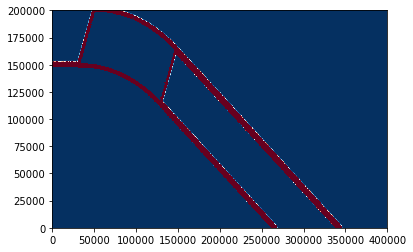

In [78]:
plt.contourf(X_low, (zmax - Z_low), div, cmap=cm.get_cmap('RdBu_r'),levels=np.linspace(0,1e-10,201),extend='both')